Matplotlib is building the font cache; this may take a moment.


Q7 Decision Tree on Iris
Depth = 1 Train acc = 0.6666666666666666 Test acc = 0.6666666666666666


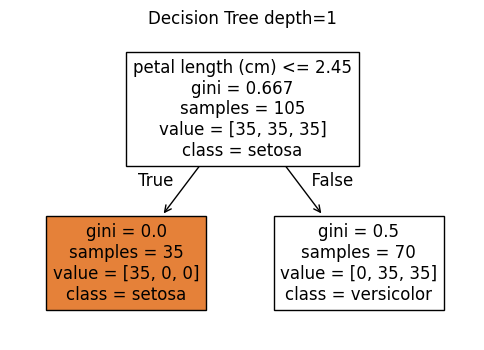

Depth = 2 Train acc = 0.9714285714285714 Test acc = 0.8888888888888888


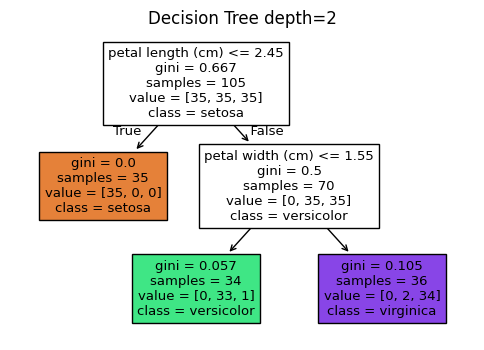

Depth = 3 Train acc = 0.9809523809523809 Test acc = 0.9777777777777777


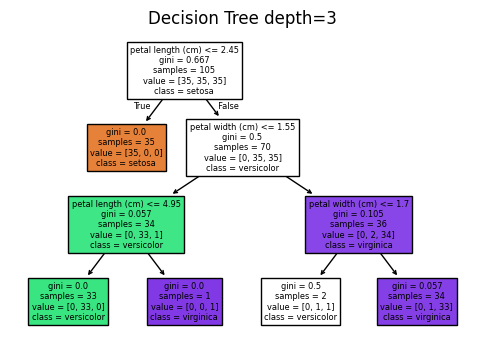

When depth=1 the model underfits, depth=3 may overfit but still works well.

Q8 kNN decision boundaries


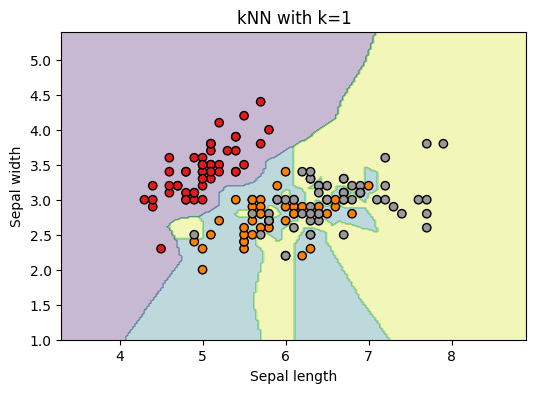

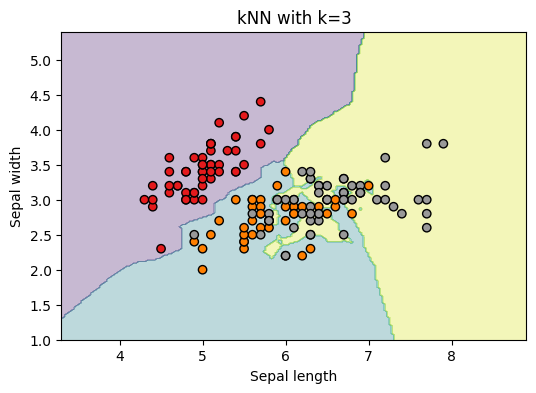

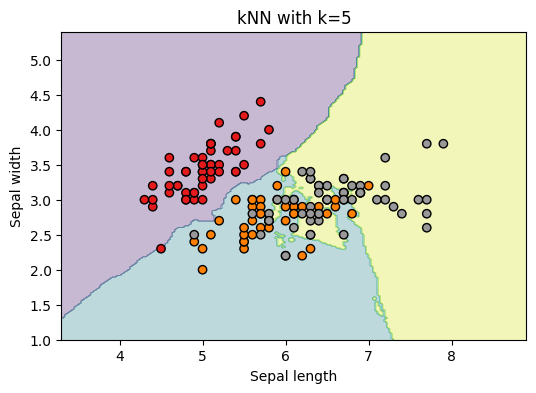

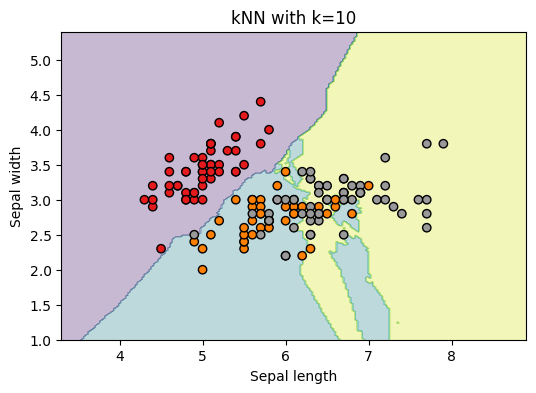

k=1 gives complex boundaries, larger k makes them smoother.

Q9 kNN performance evaluation (k=5)
Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



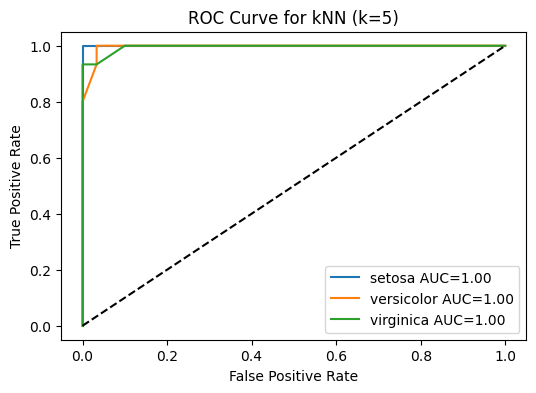

In [1]:
# Homework 2 - Part B
# CS5710 - Machine Learning
# Student: SUJAN AKENA (700770399)

# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ---------------- Q7 Decision Tree ----------------
print("Q7 Decision Tree on Iris")

for d in [1, 2, 3]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    print("Depth =", d, "Train acc =", train_acc, "Test acc =", test_acc)

    # plot the tree for visualization
    plt.figure(figsize=(6, 4))
    plot_tree(dt, filled=True, feature_names=iris.feature_names,
              class_names=iris.target_names)
    plt.title("Decision Tree depth=" + str(d))
    plt.show()

print("When depth=1 the model underfits, depth=3 may overfit but still works well.")

# ---------------- Q8 kNN boundaries ----------------
print("\nQ8 kNN decision boundaries")

# use only sepal length and width
X2 = iris.data[:, :2]
y2 = iris.target

# meshgrid for plotting regions
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

for k in [1, 3, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X2, y2)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X2[:, 0], X2[:, 1], c=y2, edgecolor="k", cmap=plt.cm.Set1)
    plt.title("kNN with k=" + str(k))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.show()

print("k=1 gives complex boundaries, larger k makes them smoother.")

# ---------------- Q9 Performance evaluation ----------------
print("\nQ9 kNN performance evaluation (k=5)")

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred = knn5.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=iris.target_names))

# ROC curve and AUC (multi-class)
y_prob = knn5.predict_proba(X_test)
y_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6, 4))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=iris.target_names[i] +
             " AUC=%.2f" % roc_auc[i])

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for kNN (k=5)")
plt.legend()
plt.show()
